<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/intelligence_system/is_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Install dependencies if not available
!pip install -q nltk pandas

# Import libraries
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
def preprocess_text(sentence):
    # Tokenization
    tokens = word_tokenize(sentence.lower())

    # Stopword removal
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if w.isalnum() and w not in stop_words]

    # Stemming
    ps = PorterStemmer()
    stemmed_tokens = [ps.stem(w) for w in filtered_tokens]

    return " ".join(stemmed_tokens), stemmed_tokens

In [7]:
# Example Documents
documents = [
    "Should we go to a pizzeria or do you prefer a restaurant?",
    "Natural Language Processing is a key part of artificial intelligence.",
    "Machine learning enables computers to learn from data.",
    "AI and data science are transforming healthcare analytics."
]

# Preprocess each document
processed_docs = []
for doc in documents:
    cleaned_text, tokens = preprocess_text(doc)
    processed_docs.append({
        "Original": doc,
        "Cleaned_Text": cleaned_text,
        "Tokens": tokens
    })

# Display preprocessed results
df = pd.DataFrame(processed_docs)
print("Preprocessed DataFrame:")
display(df)

Preprocessed DataFrame:


,Original,Cleaned_Text,Tokens
0,Should we go to a pizzeria or do you prefer a ...,go pizzeria prefer restaur,"[go, pizzeria, prefer, restaur]"
1,Natural Language Processing is a key part of a...,natur languag process key part artifici intellig,"[natur, languag, process, key, part, artifici,..."
2,Machine learning enables computers to learn fr...,machin learn enabl comput learn data,"[machin, learn, enabl, comput, learn, data]"
3,AI and data science are transforming healthcar...,ai data scienc transform healthcar analyt,"[ai, data, scienc, transform, healthcar, analyt]"


In [8]:
#one-hot encoding for a single document
import numpy as np
def one_hot_encoding(sentence):
    words = sentence.lower().split()
    vocabulary = sorted(set(words))
    word_to_index = {word: i for i, word in enumerate(vocabulary)}
    one_hot_matrix = np.zeros((len(words), len(vocabulary)), dtype=int)
    for i, word in enumerate(words):
        one_hot_matrix[i, word_to_index[word]] = 1

    return one_hot_matrix, vocabulary

# Example of usage
sentence = "Should we go to a pizzeria or do you a prefer a restaurant?"
one_hot_matrix, vocabulary = one_hot_encoding(sentence)
print("Vocabulary:", vocabulary)
print("One-Hot Encoding Matrix:\n", one_hot_matrix)

Vocabulary: ['a', 'do', 'go', 'or', 'pizzeria', 'prefer', 'restaurant?', 'should', 'to', 'we', 'you']
One-Hot Encoding Matrix:
 [[0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0]]


In [9]:
# One-Hot Encoding for Entire Vocabulary

import numpy as np

# Flatten tokens from all documents to build the full vocabulary
all_tokens = [token for sublist in df["Tokens"] for token in sublist]
vocabulary = sorted(set(all_tokens))

# Create a mapping from word to index
word_to_index = {word: i for i, word in enumerate(vocabulary)}

# Initialize matrix (documents × vocabulary)
one_hot_matrix = np.zeros((len(df), len(vocabulary)), dtype=int)

# Fill one-hot matrix for each document
for i, tokens in enumerate(df["Tokens"]):
    for token in tokens:
        if token in word_to_index:
            one_hot_matrix[i, word_to_index[token]] = 1

# Create a labeled DataFrame for better readability
one_hot_df = pd.DataFrame(one_hot_matrix, columns=vocabulary)
one_hot_df.index = [f"Doc_{i+1}" for i in range(len(df))]

print(" Vocabulary:", vocabulary)
print("\n One-Hot Encoding Matrix for All Documents:")
display(one_hot_df)


 Vocabulary: ['ai', 'analyt', 'artifici', 'comput', 'data', 'enabl', 'go', 'healthcar', 'intellig', 'key', 'languag', 'learn', 'machin', 'natur', 'part', 'pizzeria', 'prefer', 'process', 'restaur', 'scienc', 'transform']

 One-Hot Encoding Matrix for All Documents:


,ai,analyt,artifici,comput,data,enabl,go,healthcar,intellig,key,...,learn,machin,natur,part,pizzeria,prefer,process,restaur,scienc,transform
Doc_1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,1,0,1,0,0
Doc_2,0,0,1,0,0,0,0,0,1,1,...,0,0,1,1,0,0,1,0,0,0
Doc_3,0,0,0,1,1,1,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
Doc_4,1,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1


In [10]:
def bag_of_words(sentences):
    """
    Creates a bag-of-words representation of a list of documents.
    """
    tokenized_sentences = [sentence.lower().split() for sentence in sentences]
    flat_words = [word for sublist in tokenized_sentences for word in sublist]
    vocabulary = sorted(set(flat_words))
    word_to_index = {word: i for i, word in enumerate(vocabulary)}

    bow_matrix = np.zeros((len(sentences), len(vocabulary)), dtype=int)
    for i, sentence in enumerate(tokenized_sentences):
        for word in sentence:
            if word in word_to_index:
                bow_matrix[i, word_to_index[word]] += 1

    return vocabulary, bow_matrix

# Example of usage
corpus = ["This movie is awesome awesome", "I do not say is good, but neither awesome",
             "Awesome? Only a fool can say that"]
vocabulary, bow_matrix = bag_of_words(corpus)
print("Vocabulary:", vocabulary)
print("Bag of Words Matrix:\n", bow_matrix)

Vocabulary: ['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
Bag of Words Matrix:
 [[0 2 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1]
 [0 1 0 1 0 1 0 1 1 1 0 1 1 0 1 0 0]
 [1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0]]


In [11]:
def compute_tf(sentences):
    """Compute the term frequency matrix for a list of sentences."""
    vocabulary = sorted(set(word for sentence in sentences for word in sentence.lower().split()))
    word_index = {word: i for i, word in enumerate(vocabulary)}
    tf = np.zeros((len(sentences), len(vocabulary)), dtype=np.float32)
    for i, sentence in enumerate(sentences):
        words = sentence.lower().split()
        word_count = len(words)
        for word in words:
            if word in word_index:
                tf[i, word_index[word]] += 1 / word_count
    return tf, vocabulary

def compute_idf(sentences, vocabulary):
    """Compute the inverse document frequency for a list of sentences."""
    num_documents = len(sentences)
    idf = np.zeros(len(vocabulary), dtype=np.float32)
    word_index = {word: i for i, word in enumerate(vocabulary)}
    for word in vocabulary:
        df = sum(1 for sentence in sentences if word in sentence.lower().split())
        idf[word_index[word]] = np.log(num_documents / (1 + df)) + 1  # Smoothing
    return idf

def tf_idf(sentences):
    """Generate a TF-IDF matrix for a list of sentences."""
    tf, vocabulary = compute_tf(sentences)
    idf = compute_idf(sentences, vocabulary)
    tf_idf_matrix = tf * idf
    return vocabulary, tf_idf_matrix

vocabulary, tf_idf_matrix = tf_idf(corpus)
print("Vocabulary:", vocabulary)
print("TF-IDF Matrix:\n", tf_idf_matrix)

Vocabulary: ['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
TF-IDF Matrix:
 [[0.         0.4        0.         0.         0.         0.
  0.         0.         0.         0.2        0.28109303 0.
  0.         0.         0.         0.         0.28109303]
 [0.         0.11111111 0.         0.1561628  0.         0.1561628
  0.         0.1561628  0.1561628  0.11111111 0.         0.1561628
  0.1561628  0.         0.11111111 0.         0.        ]
 [0.20078073 0.         0.20078073 0.         0.20078073 0.
  0.20078073 0.         0.         0.         0.         0.
  0.         0.20078073 0.14285715 0.20078073 0.        ]]


In [12]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
#this for unzip and read the file
try:
    df=pd.read_csv("IMDB Dataset.csv")
except:
    !wget https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true
    !unzip IMDB.zip?raw=true

--2025-11-07 11:12:11--  https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/SalvatoreRa/tutorial/raw/refs/heads/main/datasets/IMDB.zip [following]
--2025-11-07 11:12:12--  https://github.com/SalvatoreRa/tutorial/raw/refs/heads/main/datasets/IMDB.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/SalvatoreRa/tutorial/refs/heads/main/datasets/IMDB.zip [following]
--2025-11-07 11:12:12--  https://raw.githubusercontent.com/SalvatoreRa/tutorial/refs/heads/main/datasets/IMDB.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.1

In [14]:
# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")
df = df.iloc[:5000,:]

# Display the first few rows of the dataframe
print(df.head())

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

# Fit and transform
tfidf_matrix = tfidf_vectorizer.fit_transform(df['review'])

# Convert the TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [15]:
# Define the query
query = "I want to watch a movie about zombie"

# Transform the query using the same TF-IDF vectorizer
query_tfidf = tfidf_vectorizer.transform([query])

# Calculate cosine similarity between the query and all documents
cosine_similarities = cosine_similarity(query_tfidf, tfidf_matrix).flatten()

df['cosine_similarity'] = cosine_similarities

reranked_df = df.sort_values(by='cosine_similarity',
                             ascending=False).reset_index(drop=True)

reranked_df

,review,sentiment,cosine_similarity
0,If you want to waste a small portion of your l...,negative,0.589198
1,This movie is god awful. Not one quality to th...,negative,0.483662
2,"Now, I'm a big fan of Zombie movies. I admit Z...",negative,0.463848
3,"""Revolt of the Zombies"" proves that having the...",negative,0.360548
4,I haven't had a chance to view the previous fi...,negative,0.343682
...,...,...,...
4995,I was rooting for this film as it's a remake o...,negative,0.000000
4996,Maybe not the most original way of telling a s...,positive,0.000000
4997,If you need cheering up on a cold weekday even...,positive,0.000000
4998,"they (dueringer, dorfer) are good stand-up com...",negative,0.000000


In [16]:
#give a look in detail to the first example
reranked_df.iloc[0,0]

'If you want to waste a small portion of your life sit in front of this predictable zombie film. It fails at the first post by not being scary OR funny. It is a dull grey movie that I guess went straight to video. Hammy and tongue in cheek acting leave a sour taste in the mouth. If you want to watch a poor but still watchable recent zombie film watch Diary of the Dead. Poor special effects, school level script. Zombie films work if they have a moral point or even a political point . This movie has nothing, there is no worthy point that zombification underscores. This is as thrilling and convincing as a Republican Convention, no sorry watching the Republican Convention would be a better example of a Zombie movie.'

In [17]:
!pip install -q gensim umap-learn tqdm adjustText

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.4 MB/s eta 0:00:00


In [18]:
import numpy as np
import pandas as pd
import os
import re
import time
import nltk
from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from adjustText import adjust_text
from umap import UMAP

In [19]:
def preprocessing_reviews(reviews):

    """
    simple preprocessing: splitting on the space and remove word less than 1 chr
    """

    processed_reviews = []

    for review in tqdm(reviews):
        review = re.sub('<[^>]+>', '', review)
        processed = re.sub('[^a-zA-Z ]', '', review)
        words = processed.split()
        processed_reviews.append(' '.join([word.lower() for word in words if len(word) > 1]))
    return processed_reviews

df['reviews_processed'] = preprocessing_reviews(df['review'])
df['tokens'] = df['reviews_processed'].apply(nltk.word_tokenize)
df.head()

100%|██████████| 5000/5000 [00:00<00:00, 10390.71it/s]


,review,sentiment,cosine_similarity,reviews_processed,tokens
0,One of the other reviewers has mentioned that ...,positive,0.025828,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,positive,0.021989,wonderful little production the filming techni...,"[wonderful, little, production, the, filming, ..."
2,I thought this was a wonderful way to spend ti...,positive,0.019862,thought this was wonderful way to spend time o...,"[thought, this, was, wonderful, way, to, spend..."
3,Basically there's a family where a little boy ...,negative,0.267357,basically theres family where little boy jake ...,"[basically, theres, family, where, little, boy..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,0.063951,petter matteis love in the time of money is vi...,"[petter, matteis, love, in, the, time, of, mon..."


In [22]:
start_time = time.time()
# embedding
model = Word2Vec(sentences=df['tokens'].tolist(),
                 sg=1,
                 vector_size=100,
                 window=5,
                 workers=4)

print(f'Time needed : {(time.time() - start_time) / 60:.2f} mins')

Time needed : 0.40 mins


In [25]:
all_words = list(model.wv.index_to_key)

# Convert to DataFrame for easier viewing
embedding = model.wv.vectors
embedding_df = pd.DataFrame(embedding, index=all_words)

# Display first few embeddings
print("\n=== Word Embeddings Sample ===")
display(embedding_df.head(10))

# display embedding for a specific word
word = 'love'  # <-- change to any word in your vocab
if word in model.wv:
    print(f"\nEmbedding for '{word}':\n", model.wv[word])
else:
    print(f"\nWord '{word}' not in vocabulary.")


=== Word Embeddings Sample ===


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
the,-0.121845,0.107839,0.109526,0.059934,-0.173740,-0.255951,0.059682,0.512780,-0.159770,-0.318369,...,0.307560,-0.205618,-0.051621,-0.245876,0.513043,0.181814,0.096648,-0.114867,0.194154,0.053068
and,0.087369,0.337885,0.079089,0.176375,-0.004676,-0.388820,-0.219481,0.302371,-0.073676,-0.371870,...,0.261247,0.059526,-0.024968,0.042588,0.236542,0.134153,-0.053385,-0.146690,-0.075615,-0.073722
of,0.037839,-0.009444,-0.179718,-0.166280,-0.077591,-0.179037,-0.143517,0.272894,-0.091432,-0.107269,...,0.008828,-0.184964,0.015742,0.029056,0.621503,0.308396,0.080882,0.078658,0.175774,0.153324
to,-0.130388,0.121932,0.093791,-0.005514,0.152454,-0.427484,0.323446,0.401182,0.243291,-0.107727,...,0.154674,-0.027180,-0.025979,-0.195478,0.438005,0.527262,-0.220545,-0.277280,-0.072324,-0.265114
is,-0.409450,0.201965,-0.164228,0.048550,-0.306933,-0.115080,-0.054678,0.567343,0.376255,-0.200263,...,0.142501,-0.303803,-0.028442,0.214112,0.527321,0.149098,0.022474,0.035813,-0.018873,0.156271
in,-0.002352,0.150929,-0.020534,-0.230989,-0.095018,-0.102557,-0.009907,0.646099,-0.045546,0.094427,...,0.447808,-0.143046,-0.399537,0.016530,0.413046,0.129462,0.035467,-0.428928,0.343953,-0.386650
it,0.110909,0.350382,-0.099553,0.016467,-0.210821,-0.231371,0.244952,0.308108,-0.332571,-0.059451,...,0.427976,0.020733,0.053069,-0.083842,0.102284,0.246358,-0.004957,-0.088369,0.011536,0.001231
this,0.059601,0.154606,0.211091,0.138484,-0.273764,-0.371301,0.209346,0.476739,-0.101507,-0.136876,...,0.280954,0.092257,-0.274240,0.079317,0.169627,-0.016528,-0.151070,0.026517,-0.003916,0.025391
that,0.095923,0.456636,0.029405,-0.010560,-0.052091,-0.181529,0.003355,0.412537,0.044097,0.014044,...,0.142862,-0.167358,0.179963,0.080699,0.411043,0.211944,0.062540,-0.101319,0.158743,-0.153719
was,-0.105243,0.108447,-0.435230,0.338823,-0.310904,-0.294273,-0.123117,0.674073,-0.014964,-0.097108,...,0.130391,0.233819,-0.051220,0.146837,0.391051,0.108561,-0.293100,0.078252,0.296044,0.160147



Embedding for 'love':
 [ 0.17511085  0.3424372   0.06019254  0.2866872   0.17534399 -0.1528225
  0.38319746  0.56166273 -0.15104887 -0.43015233 -0.15439402 -0.15104696
 -0.26497713  0.21989761  0.1242168   0.08285502 -0.4703353   0.37656075
 -0.28912225 -0.2939694  -0.2765927  -0.2261593   0.14909282 -0.34538865
 -0.1099815  -0.21551304 -0.43586498 -0.00678281 -0.25303262  0.38864875
 -0.09124376  0.16077122 -0.09224808 -0.10890687 -0.09529588  0.6170085
 -0.00303678 -0.16511844 -0.5496507   0.1803397  -0.3561312  -0.38383907
 -0.34694204 -0.06292185  0.05553374 -0.46171296 -0.10397764 -0.30612767
  0.34496385  0.486299    0.5989188  -0.35275704  0.43778792  0.3410771
  0.22559349  0.02690594  0.31285745  0.1087566  -0.21094462  0.2542465
  0.04732406 -0.04822044 -0.15196833 -0.27154467 -0.12352357  0.3342076
  0.22185548  0.28291866 -0.20115452  0.38676995 -0.12096567  0.27038792
  0.27740344  0.04096758  0.11622714  0.38633472  0.32662842  0.27700508
 -0.19421907 -0.01135398 -0.1568

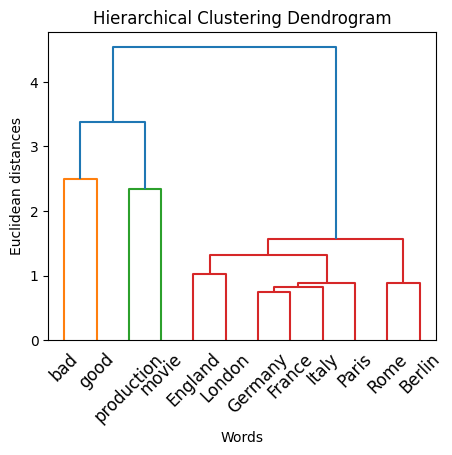

In [26]:
# Entire set of words in the model
all_words = list(model.wv.index_to_key)
all_vectors = np.array([model.wv[word] for word in all_words])

# Highlighted words and their vectors
highlight_words = ['Berlin', 'Paris', 'London','Rome', 'Italy',
                   'France', 'Germany', 'England', 'movie', 'production', 'good', 'bad']
highs = [w.lower() for w in highlight_words]
indices = [all_words.index(word) for word in highs if word in all_words]
highlight_vectors = np.array([all_vectors[index] for index in indices])

linked = linkage(highlight_vectors, 'ward')

plt.figure(figsize=(5, 4))
dendrogram(linked,
           orientation='top',
           labels=highlight_words,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Words')
plt.ylabel('Euclidean distances')
plt.xticks(rotation=45)
plt.savefig('word_dendrogram.jpg', format='jpeg', bbox_inches='tight')
plt.show()

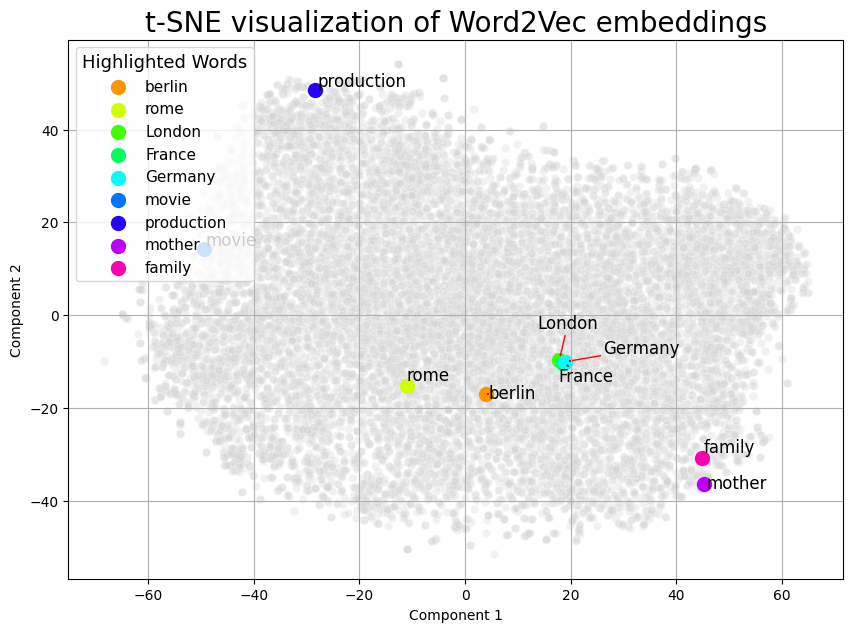

In [27]:
# Apply t-SNE to the entire set of vectors
tsne = TSNE(n_components=2, random_state=0)
Y_tsne = tsne.fit_transform(all_vectors)

highlight_words = ['berlin', 'rome', 'London', 'France', 'Germany',
                    'movie', 'production', 'mother', 'family']

highs = [w.lower() for w in highlight_words]
indices = [all_words.index(word) for word in highs if word in all_words]
highlight_vectors = np.array([all_vectors[index] for index in indices])
Y_highlight = Y_tsne[indices]


plt.figure(figsize=(10, 7))


sns.scatterplot(x=Y_tsne[:, 0], y=Y_tsne[:, 1], color="lightgrey", alpha=0.3)

# Plot highlighted words
palette = sns.color_palette("hsv", len(highlight_words))
texts = []
for i, word in enumerate(highlight_words):
    plt.scatter(Y_highlight[i, 0], Y_highlight[i, 1], color=palette[i], s=100, label=word)
    # adjust text
    texts.append(plt.text(Y_highlight[i, 0], Y_highlight[i, 1], word, fontsize=12))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('t-SNE visualization of Word2Vec embeddings', fontsize=20)
plt.xlabel('Component 1')
plt.ylabel('Component 2')


plt.grid(True)
plt.legend(title='Highlighted Words', title_fontsize='13', fontsize='11')
plt.savefig('word_tsne.jpg', format='jpeg')
plt.show()

/tmp/ipython-input-1974943856.py:19: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(v1, v2) < 0:


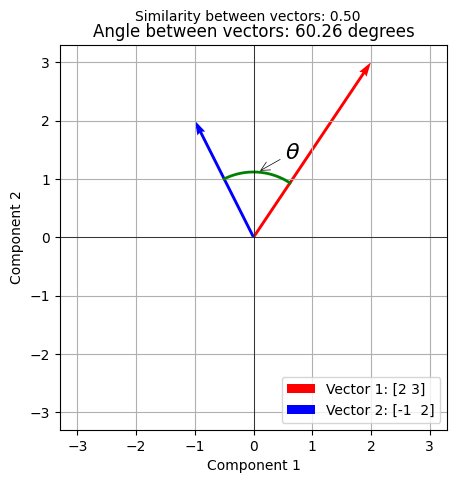

In [28]:
def plot_vectors_and_angle(v1, v2):

    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    cosine_similarity = dot_product / (norm_v1 * norm_v2)
    angle_radians = np.arccos(cosine_similarity)
    angle_degrees = np.degrees(angle_radians)


    fig, ax = plt.subplots(figsize=(5, 5))


    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label=f"Vector 1: {v1}")
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label=f"Vector 2: {v2}")


    start_angle = np.arctan2(v1[1], v1[0])
    if np.cross(v1, v2) < 0:
        angle_radians = -angle_radians


    theta = np.linspace(start_angle, start_angle + angle_radians, 100)
    r = 0.5 * min(np.linalg.norm(v1), np.linalg.norm(v2))
    x = r * np.cos(theta)
    y = r * np.sin(theta)


    ax.plot(x, y, linestyle='-', color='green', lw=2)


    midpoint = (start_angle + angle_radians / 2)
    ax.annotate(r'$\theta$', xy=(r * np.cos(midpoint), r * np.sin(midpoint)), xytext=(20, 10),
                textcoords='offset points', fontsize=16, arrowprops=dict(arrowstyle='->', lw=0.5))


    max_range = np.max(np.abs(np.vstack([v1, v2, [x.max(), y.max()]]))) * 1.1  # 10% padding
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])


    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(f'Angle between vectors: {angle_degrees:.2f} degrees')
    plt.suptitle(f'Similarity between vectors: {cosine_similarity:.2f}', fontsize=10, y=.95)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend(loc='lower right')
    plt.savefig('cosine_similarity.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

    return cosine_similarity, angle_degrees

# Example usage
v1 = np.array([2, 3])
v2 = np.array([-1, 2])
cos_sim, angle = plot_vectors_and_angle(v1, v2)

In [29]:
word_1 = "good"
syn = "great"
ant = "bad"
most_sim =model.wv.most_similar("good")
print("Top 3 most simalr words to {} are :{}".format(word_1, most_sim[:3]))

synonyms_dist = model.wv.distance(word_1, syn)
antonyms_dist = model.wv.distance(word_1, ant)
print("Synonyms {}, {} have cosine distance: {}".format(word_1, syn, synonyms_dist))
print("Antonyms {}, {} have cosine distance: {}".format(word_1, ant, antonyms_dist))
a = 'king'
a_star = 'man'
b = 'woman'
b_star= model.wv.most_similar(positive=[a, b], negative=[a_star])
print("{} is to {} as {} is to: {} ".format(a, a_star, b, b_star[0][0]))

Top 3 most simalr words to good are :[('decent', 0.7507211565971375), ('great', 0.7441223859786987), ('soso', 0.703815758228302)]
Synonyms good, great have cosine distance: 0.2558777332305908
Antonyms good, bad have cosine distance: 0.3475427031517029
king is to man as woman is to: carol 


In [30]:
!pip install -q sentence-transformers scikit-learn matplotlib

In [31]:
# --- Step 2: Import Libraries ---
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

In [34]:
#Load Pretrained Embedding Model ---
# You can replace this model with others like "all-MiniLM-L6-v2" or "paraphrase-MiniLM-L3-v2"
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [35]:
#Example Sentences ---
sentences = [
    "Cats are wonderful pets.",
    "Dogs are loyal and friendly.",
    "The sky is blue and clear today.",
    "I love to play with my dog.",
    "Artificial intelligence is transforming healthcare."
]

In [36]:
#display embedding of a single word
word = "pets"
# Generate embedding
embedding = model.encode(word)

print(f"Shape of embedding vector: {embedding.shape}")
print("Embedding values (first 10 dimensions):", embedding[:10])

Shape of embedding vector: (384,)
Embedding values (first 10 dimensions): [ 7.98710529e-03  1.01199020e-02  3.97333726e-02  5.19030727e-02
 -1.06959075e-01  9.81654375e-05  7.06559867e-02 -5.11679538e-02
  5.48837185e-02  2.15079729e-02]


In [37]:
sentence_embeddings = model.encode(sentences)
for i, sentence in enumerate(sentences):
    print(f"Sentence: {sentence}")
    print(f"Sentence embedding shape: {sentence_embeddings[i].shape}")
    print(f"First 10 dimensions: {sentence_embeddings[i][:10]}\n")

    # Generate embeddings for each word (approximation using the same model)
    words = sentence.split()
    for word in words:
        word_embedding = model.encode(word)
        print(f"  Word: {word}")
        print(f"  Embedding shape: {word_embedding.shape}")
        print(f"  First 10 dimensions: {word_embedding[:10]}\n")

    print("-" * 80)

Sentence: Cats are wonderful pets.
Sentence embedding shape: (384,)
First 10 dimensions: [ 0.07260352  0.01278538  0.09712934  0.01684646 -0.1433138   0.00660507
  0.01337401 -0.02314304 -0.01346145  0.02695632]

  Word: Cats
  Embedding shape: (384,)
  First 10 dimensions: [ 0.03606861  0.02692948  0.00767731  0.06736805 -0.08742581 -0.01713079
  0.10187887 -0.02700192  0.04178691  0.01190578]

  Word: are
  Embedding shape: (384,)
  First 10 dimensions: [-0.00790854  0.04488925  0.00858014  0.03389966 -0.05833887  0.01632328
  0.06284717 -0.03925535  0.05013675  0.04733051]

  Word: wonderful
  Embedding shape: (384,)
  First 10 dimensions: [-0.08132238 -0.01762178 -0.02899454 -0.02423161  0.01959453 -0.06225199
  0.008061    0.0245816  -0.01809038 -0.00761437]

  Word: pets.
  Embedding shape: (384,)
  First 10 dimensions: [ 0.00933743  0.01224204  0.03138565  0.06878854 -0.10450595  0.00452371
  0.0792317  -0.06149326  0.04155992  0.00968963]

--------------------------------------

In [38]:
# Generate Sentence Embeddings ---
#embeddings = model.encode(sentences)

print("Embeddings Generated!")
print(f"Shape of embedding matrix: {sentence_embeddings.shape}")

Embeddings Generated!
Shape of embedding matrix: (5, 384)


In [39]:
#Calculate similarities in sentenses
similarity_matrix = model.similarity(sentence_embeddings, sentence_embeddings)
print("\nCosine Similarity Between Sentences:\n")
print(similarity_matrix)


Cosine Similarity Between Sentences:

tensor([[ 1.0000,  0.5055,  0.0583,  0.4395,  0.1039],
        [ 0.5055,  1.0000,  0.0176,  0.5127, -0.0222],
        [ 0.0583,  0.0176,  1.0000, -0.0037,  0.0909],
        [ 0.4395,  0.5127, -0.0037,  1.0000,  0.1084],
        [ 0.1039, -0.0222,  0.0909,  0.1084,  1.0000]])


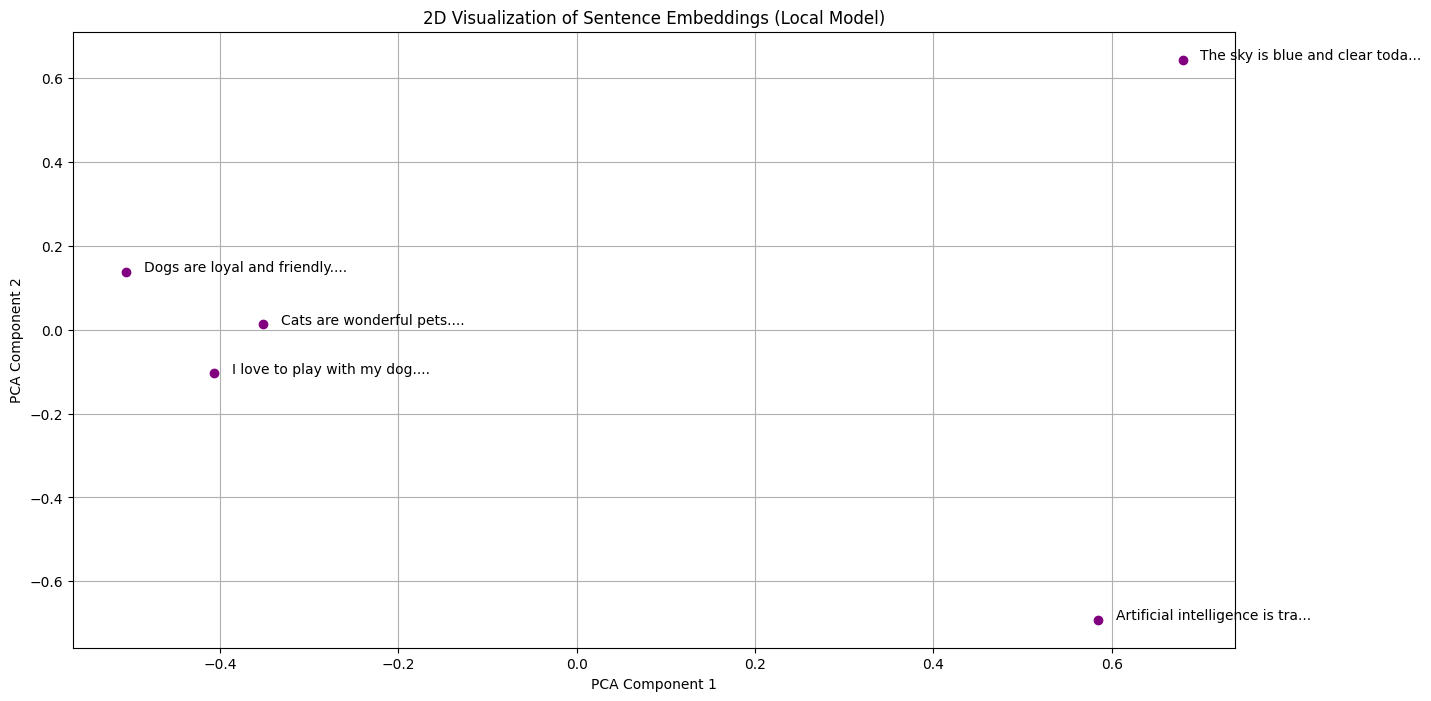

In [40]:
# Visualize in 2D Using PCA ---
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(sentence_embeddings)

plt.figure(figsize=(15,8))
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], color='purple')

for i, sentence in enumerate(sentences):
    plt.annotate(sentence[:30] + "...", (reduced_embeddings[i,0]+0.02, reduced_embeddings[i,1]))

plt.title("2D Visualization of Sentence Embeddings (Local Model)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

In [41]:
%%capture
!pip install -q transformers>=4.40.1 accelerate>=0.27.2

In [42]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [44]:
print(model)
# Explore models architecture

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_featur

In [45]:
# Define prompt
prompt = "Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened.<|assistant|>"

# Tokenize input properly
inputs = tokenizer(prompt, return_tensors="pt")

# Generate text
generation_output = model.generate(
    input_ids=inputs["input_ids"],
    max_new_tokens=20,
    do_sample=True,
    temperature=0.7
)

# Decode and print result
output_text = tokenizer.decode(generation_output[0], skip_special_tokens=True)
print(output_text)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened. Subject: My Deepest Apologies for the Gardening Misfortune


Dear


In [46]:
print(inputs["input_ids"])

tensor([[14350,   385,  4876, 27746,  5281,   304, 19235,   363,   278, 25305,
           293, 16423,   292,   286,   728,   481, 29889, 12027,  7420,   920,
           372,  9559, 29889, 32001]])


In [47]:
# Print token IDs and decoded tokens for the input
print("\nToken IDs:", inputs["input_ids"][0].tolist())
print("\nDecoded tokens:")
for token_id in inputs["input_ids"][0]:
    print(f"{token_id.item()} -> {tokenizer.decode(token_id)}")


Token IDs: [14350, 385, 4876, 27746, 5281, 304, 19235, 363, 278, 25305, 293, 16423, 292, 286, 728, 481, 29889, 12027, 7420, 920, 372, 9559, 29889, 32001]

Decoded tokens:
14350 -> Write
385 -> an
4876 -> email
27746 -> apolog
5281 -> izing
304 -> to
19235 -> Sarah
363 -> for
278 -> the
25305 -> trag
293 -> ic
16423 -> garden
292 -> ing
286 -> m
728 -> ish
481 -> ap
29889 -> .
12027 -> Exp
7420 -> lain
920 -> how
372 -> it
9559 -> happened
29889 -> .
32001 -> <|assistant|>


In [48]:
# Print token IDs and decoded tokens for the generated output
print("\n=== Generated Tokens ===")
gen_token_ids = generation_output[0]
print("Token IDs:", gen_token_ids.tolist())
print("Tokens:")
for token_id in gen_token_ids:
    print(f"{token_id.item()} -> '{tokenizer.decode(token_id)}'")


=== Generated Tokens ===
Token IDs: [14350, 385, 4876, 27746, 5281, 304, 19235, 363, 278, 25305, 293, 16423, 292, 286, 728, 481, 29889, 12027, 7420, 920, 372, 9559, 29889, 32001, 3323, 622, 29901, 1619, 21784, 342, 6225, 11763, 363, 278, 19906, 292, 20929, 3921, 1540, 13, 13, 13, 29928, 799]
Tokens:
14350 -> 'Write'
385 -> 'an'
4876 -> 'email'
27746 -> 'apolog'
5281 -> 'izing'
304 -> 'to'
19235 -> 'Sarah'
363 -> 'for'
278 -> 'the'
25305 -> 'trag'
293 -> 'ic'
16423 -> 'garden'
292 -> 'ing'
286 -> 'm'
728 -> 'ish'
481 -> 'ap'
29889 -> '.'
12027 -> 'Exp'
7420 -> 'lain'
920 -> 'how'
372 -> 'it'
9559 -> 'happened'
29889 -> '.'
32001 -> '<|assistant|>'
3323 -> 'Sub'
622 -> 'ject'
29901 -> ':'
1619 -> 'My'
21784 -> 'Deep'
342 -> 'est'
6225 -> 'Ap'
11763 -> 'ologies'
363 -> 'for'
278 -> 'the'
19906 -> 'Garden'
292 -> 'ing'
20929 -> 'Mis'
3921 -> 'fort'
1540 -> 'une'
13 -> '
'
13 -> '
'
13 -> '
'
29928 -> 'D'
799 -> 'ear'


In [49]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
